# Configuration

In [3]:
import sys
import code
import os
import pickle

import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np

from tqdm import tqdm
import scipy.sparse
from scipy.sparse import csr_matrix
from gtfparse import read_gtf
from collections import defaultdict
from sklearn.metrics import auc, precision_recall_curve, average_precision_score

sys.path.append('/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/')

# 1. 加载 autoreload 扩展
%load_ext autoreload

# 2. 设置模式为 "2" (表示自动重载所有模块)
%autoreload 2



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
from pdata.data_read import read_unibind_file

cell_type = "GM12878"

data_path = "/home/liyang/BioWuYan/dygmamba_project/data/cell_line/" + cell_type + "/process/"

output_path = "/home/liyang/BioWuYan/dygmamba_project/data/cell_line/" + cell_type + "/benchmark/"

os.makedirs(output_path, exist_ok=True )

###########################################################
# Unibind data processing

unibind_file = "/home/liyang/BioWuYan/dygmamba_project/data/cell_line/GM12878/unibind/GM12878_UniBind.tar.gz"

unibind_df, count_region_df = read_unibind_file(unibind_file)

unibind_df["CellLine"] = unibind_df["CellLine"].str.split('_').str[0]
count_region_df["CellLine"] = count_region_df["CellLine"].str.split('_').str[0]

print(unibind_df.head())
print(count_region_df.head())

unibind_df.to_pickle(output_path + "unibind_df.pkl")
count_region_df.to_pickle(output_path + "count_region_df.pkl")




********** 开始读取数据...
正在读取压缩包: /home/liyang/BioWuYan/dygmamba_project/data/cell_line/GM12878/unibind/GM12878_UniBind.tar.gz ...
处理完成！
共提取了 78 个 TF 的数据。
总 Region 数量: 2149506
  chrom   start     end    TF CellLine     SourceID
0  chr1  869917  869936  CTCF  GM12878  ENCSR000AKB
1  chr1  904767  904786  CTCF  GM12878  ENCSR000AKB
2  chr1  938241  938260  CTCF  GM12878  ENCSR000AKB
3  chr1  976207  976226  CTCF  GM12878  ENCSR000AKB
4  chr1  984316  984335  CTCF  GM12878  ENCSR000AKB
   CellLine     TF  PeakCount  Rank
60  GM12878  RUNX3      82726   1.0
64  GM12878   SPI1      71614   2.0
77  GM12878    YY1      67878   3.0
16  GM12878   EBF1      63565   4.0
6   GM12878   BATF      51722   5.0


# Other TF-recovery

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Top 40 AUC (Raw): 611.00
Top 40 AUC (Normalized): 0.7642


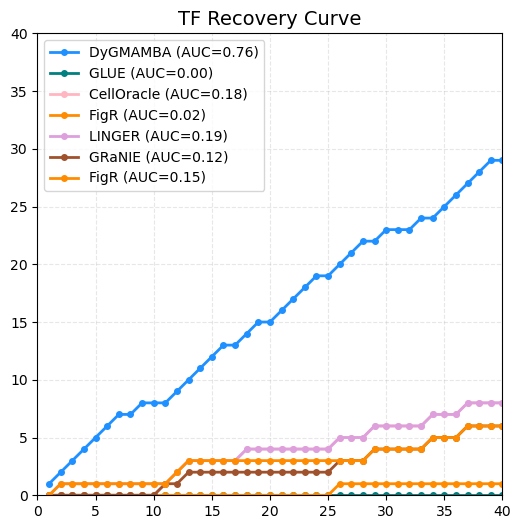

In [5]:
import sys
import os
import pickle
import pandas as pd
import anndata as ad
import numpy as np
import networkx as nx
from tqdm import tqdm
import scipy.sparse
from sklearn.metrics import auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt



# 1. 加载 autoreload 扩展
%load_ext autoreload

# 2. 设置模式为 "2" (表示自动重载所有模块)
%autoreload 2

sys.path.append('/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/')

from analysis.assess_tf_recovery import calculate_recovery_metrics
from pdata.benchmark_data import glue_read_ctx_grn

##############################################################################
#
#
##############################################################################

cell_type = "GM12878"

data_path = "/home/liyang/BioWuYan/dygmamba_project/data/cell_line/" + cell_type + "/"

output_path = "/home/liyang/BioWuYan/dygmamba_project/data/cell_line/" + cell_type + "/benchmark/"

os.makedirs(output_path, exist_ok=True)

###########################################################
# Unibind data processing
 
benchmark_df = pd.read_pickle(output_path + "count_region_df.pkl")

ground_truth_ranked = benchmark_df.sort_values(by="PeakCount", ascending=False)["TF"].tolist()



##########################################################################
# DygMamba TF recovery
tf_peak_grn = ad.read_h5ad(data_path + "process/tf_peak_network.h5ad")

dyg_tfs = set(tf_peak_grn.var_names)

dyg_x, dyg_y, dyg_raw_auc, dyg_norm_auc = calculate_recovery_metrics(ground_truth_ranked, dyg_tfs, top_n=40)

print(f"Top 40 AUC (Raw): {dyg_raw_auc:.2f}")
print(f"Top 40 AUC (Normalized): {dyg_norm_auc:.4f}")

plt.figure(figsize=(6, 6))

# 绘制我们的方法的曲线
plt.plot(dyg_x, dyg_y, label=f'{"DyGMAMBA"} (AUC={dyg_norm_auc:.2f})', color='dodgerblue', linewidth=2, marker='o', markersize=4)

##########################################################################
# GLUE TF recovery

glue_grn = glue_read_ctx_grn(data_path + "data_glue/pruned_grn.csv")


df_edges = nx.to_pandas_edgelist(glue_grn, source="TF", target="Gene")

glue_tfs = set(df_edges["TF"])

glue_x, glue_y, glue_raw_auc, glue_norm_auc = calculate_recovery_metrics(ground_truth_ranked, glue_tfs, top_n=40)

plt.plot(glue_x, glue_y, label=f'{"GLUE"} (AUC={glue_norm_auc:.2f})', color='teal', linewidth=2, marker='o', markersize=4)

##########################################################################
# CellOracle TF recovery

celloracle_grn = pd.read_csv(data_path + "data_celloracle/celloracle_results/grn_df_" + "cluster0" + ".csv")

celloracle_grn.rename(columns={"source": "TF", "target": "Gene"}, inplace= True)

oracle_tf_gene = celloracle_grn[["TF", "Gene", "-logp"]].copy()

oracle_tfs = set(oracle_tf_gene["TF"])

oracle_x, oracle_y, oracle_raw_auc, oracle_norm_auc = calculate_recovery_metrics(ground_truth_ranked, oracle_tfs, top_n=40)

plt.plot(oracle_x, oracle_y, label=f'{"CellOracle"} (AUC={oracle_norm_auc:.2f})', color='lightpink', linewidth=2, marker='o', markersize=4)


##########################################################################
# FigR TF recovery

figr_grn = pd.read_csv(data_path + "data_FigR/TF_Gene_Network.csv")

figr_tfs = set(figr_grn["TF"])

figr_x, figr_y, figr_raw_auc, figr_norm_auc = calculate_recovery_metrics(ground_truth_ranked, figr_tfs, top_n=40)

plt.plot(figr_x, figr_y, label=f'{"FigR"} (AUC={figr_norm_auc:.2f})', 
         color='darkorange', linewidth=2, marker='o', markersize=4)

##########################################################################
# Linger TF recovery

linger_grn = pd.read_csv(data_path + "data_linger/train/cell_population_TF_RE_binding.txt", sep='\t')

linger_tfs = set(linger_grn.columns[1:])

linger_x, linger_y, linger_raw_auc, linger_norm_auc = calculate_recovery_metrics(ground_truth_ranked, linger_tfs, top_n=40)

plt.plot(linger_x, linger_y, label=f'{"LINGER"} (AUC={linger_norm_auc:.2f})', 
         color='plum', linewidth=2, marker='o', markersize=4)

##########################################################################
# GRaNIE TF recovery

granie_grn = pd.read_csv(data_path + "GRaNIE_output/GRaNIE_tf_gene_Links.csv")

granie_tfs = set(granie_grn["TF.name"])

granie_x, granie_y, granie_raw_auc, granie_norm_auc = calculate_recovery_metrics(ground_truth_ranked, granie_tfs, top_n=40)

plt.plot(granie_x, granie_y, label=f'{"GRaNIE"} (AUC={granie_norm_auc:.2f})', 
         color='sienna', linewidth=2, marker='o', markersize=4)


##########################################################################
# Pando TF recovery

pando_grn = pd.read_csv(data_path + "data_pando/tf_gene_network.csv")

pando_tfs = set(pando_grn["TF"])

pando_x, pando_y, pando_raw_auc, pando_norm_auc = calculate_recovery_metrics(ground_truth_ranked, pando_tfs, top_n=40)

plt.plot(pando_x, pando_y, label=f'{"FigR"} (AUC={pando_norm_auc:.2f})', 
         color='darkorange', linewidth=2, marker='o', markersize=4)


############################################################################
plt.title('TF Recovery Curve', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.xlim(0, 40)
plt.ylim(0, 40) # 或者是实际恢复的最大值

plt.savefig(output_path + 'Benchmark of TF Recovery Curve.png', dpi=1200, bbox_inches='tight')


# Other TF-Gene

## TF-Gene Network

In [13]:
from pdata.data_preprocess import filter_jaspar_tf, adata_to_dataframe

cell_type = "GM12878"

data_path = "/home/liyang/BioWuYan/dygmamba_project/data/cell_line/" + cell_type + "/process/"

output_path = "/home/liyang/BioWuYan/dygmamba_project/data/cell_line/" + cell_type + "/benchmark/"

unibind_df_file = "/home/liyang/BioWuYan/dygmamba_project/data/cell_line/" + cell_type + "/benchmark/unibind_df.pkl"

model_result_path = "/home/liyang/BioWuYan/dygmamba_project/data/cell_line/" + cell_type + "/data_dyg/"

os.makedirs(output_path, exist_ok=True )

adata_atac = ad.read_h5ad(data_path + "atac_processed.h5ad")
adata_rna = ad.read_h5ad(data_path + "rna_processed.h5ad")
total_peak = set(adata_atac.var_names)

##################################################################
########################################################################################

jaspar_tf_region_file = data_path + "jaspar_data_processed.h5ad"
jaspar_data = ad.read_h5ad(jaspar_tf_region_file)
adata_region_tf = filter_jaspar_tf(jaspar_data)


coo_matrix = adata_region_tf.X.tocoo()
tf_peak_df = pd.DataFrame({
    'Peak': adata_region_tf.obs_names[coo_matrix.row],
    'TF': adata_region_tf.var_names[coo_matrix.col],
    'value': coo_matrix.data
})
tf_peak_df = tf_peak_df[tf_peak_df['TF'].isin(set(adata_rna.var_names))]
tf_peak_df = tf_peak_df[tf_peak_df["Peak"].isin(set(adata_atac.var_names))]

print("*"*50)
print(adata_region_tf)
print(f"TF-Peak: {tf_peak_df['TF'].nunique()}, {tf_peak_df['Peak'].nunique()}, edge: {len(tf_peak_df)}")
print("*"*50)

dygmamba_tf_peak_df = tf_peak_df
dygmamba_tf_peak_df = dygmamba_tf_peak_df.rename(columns={"value":"predict"})

total_peak = set(adata_atac.var_names)
dygmamba_tf_peak_df = dygmamba_tf_peak_df[dygmamba_tf_peak_df["Peak"].isin(total_peak)].copy()

########################################################################################

feat_path = model_result_path + "edge_features.npy"
edge_label_path = model_result_path + "edge_labels.npy"

Edge_feature = np.load(feat_path, mmap_mode="r")
Edge_feature = Edge_feature.reshape(-1,1).copy()
Edge_label = np.load(edge_label_path, mmap_mode="r")
Edge_label = Edge_label.reshape(-1,1).copy()

with open(model_result_path + "node_feature_data.pkl", "rb") as f:
    load_data = pickle.load(f)

Node_feature = load_data['node_feature']

Node_id = pd.read_pickle(model_result_path + "node_id.pkl")

graph_df = pd.read_pickle(model_result_path + "Graph_df.pkl")
graph_df["Unnamed"] = graph_df.index
name_list = ["Unnamed", "source_node", "target_node", "time", "label", "edge_idx"]
New_Graph = graph_df[name_list].copy()
New_Graph.columns = ['Unnamed: 0', 'u', 'i', 'ts', 'label', 'idx']


####################################################################################

####################################################################################
result_path = model_result_path + 'my_result_run0.npy'
predict_edge_label = np.load(result_path)

New_Graph["predict"] = predict_edge_label
predict_grn = New_Graph.copy()

mapping_series = Node_id["name"]
predict_grn['source'] = (predict_grn['u'] - 1).map(mapping_series)
predict_grn['target'] = (predict_grn['i'] - 1).map(mapping_series)

peak_gene_df = predict_grn[['source', 'target', 'ts','predict']].rename(
    columns={'source': 'Peak', 'target': 'Gene'}
)
peak_gene_df = peak_gene_df[~peak_gene_df["Gene"].str.startswith('chr')].copy()

print("*"*50)
print(f"Peak-Gene: {peak_gene_df['Peak'].nunique()}, {peak_gene_df['Gene'].nunique()}, edge:{len(peak_gene_df)}")
print("*"*50)

#################################################################################### 
dygmamba_tf_peak_df = dygmamba_tf_peak_df.rename(columns={"predict":"value"})
peak_gene_grn = peak_gene_df[peak_gene_df["Peak"].isin(total_peak)]
merged_df = pd.merge(dygmamba_tf_peak_df, peak_gene_grn, on='Peak')

tf_gene_grn = merged_df.groupby(['TF', 'Gene', 'ts']).agg(
    peak_num=('Peak', 'nunique'),   # 对 Peak 列做去重计数，新列名叫 peak_num
    avg_weight=('predict', 'mean'),  # 对 weight 列做均值，新列名叫 avg_weight
    total_weight=('predict', 'sum')  # (可选) 建议顺便算个总权重
).reset_index()

# 查看结果
print("*"*50)
print(f"Dygmamba TF-Peak: {dygmamba_tf_peak_df['TF'].nunique()}, {dygmamba_tf_peak_df['Peak'].nunique()},\
    edge: {len(dygmamba_tf_peak_df)}")
print(f"Peak-Gene: {peak_gene_df['Peak'].nunique()}, {peak_gene_df['Gene'].nunique()}, edge:{len(peak_gene_df)}")
print(f"TF-Gene: {tf_gene_grn['TF'].nunique()}, {tf_gene_grn['Gene'].nunique()}, edge: {len(tf_gene_grn)}")

tf_gene_grn.to_pickle(model_result_path + "new_tf_gene_grn_1224.pkl")

avg_active_tf_gene_grn = tf_gene_grn.groupby(['TF', 'Gene']).agg(
    avg_ts_weight=('total_weight', 'mean'),  # 对 weight 列做均值，新列名叫 avg_weight
    avg_total_weight=('total_weight', 'sum')  # (可选) 建议顺便算个总权重
).reset_index()
avg_active_tf_gene_grn.to_pickle(model_result_path + "average_active_tf_gene_grn.pkl")

pivoted_grn = tf_gene_grn.pivot_table(
    index=['TF', 'Gene'],
    columns='ts',
    values='total_weight',
    fill_value=0
)
pivoted_grn['average_active_weight'] = pivoted_grn.mean(axis=1)
avg_global_tf_gene_grn = pivoted_grn.reset_index()
avg_global_tf_gene_grn = avg_global_tf_gene_grn[["TF","Gene","average_active_weight"]].copy()
avg_global_tf_gene_grn.columns.name = None
avg_global_tf_gene_grn.to_pickle(model_result_path + "average_global_tf_gene_grn.pkl")

print("*"*50)
print(f"TF-Gene: {tf_gene_grn['TF'].nunique()}, {tf_gene_grn['Gene'].nunique()}, edge: {len(tf_gene_grn)}")
print(f"avg active TF-Gene: {avg_active_tf_gene_grn['TF'].nunique()}, {avg_active_tf_gene_grn['Gene'].nunique()},\
    edge: {len(avg_active_tf_gene_grn)}")
print(f"avg global TF-Gene: {avg_global_tf_gene_grn['TF'].nunique()}, {avg_global_tf_gene_grn['Gene'].nunique()},\
    edge: {len(avg_global_tf_gene_grn)}")
print("*"*50)


步骤 1: 过滤 Peaks (行)
  > 找到 72283 / 72283 个 peaks 至少有 1 个 TF 结合。

步骤 2: 过滤 TFs (列)
  > 找到 849 / 849 个 TFs 至少结合 1 个 peak。
  > 最终形状: (72283, 849)
**************************************************
AnnData object with n_obs × n_vars = 72283 × 849
TF-Peak: 54, 31228, edge: 370236
**************************************************
**************************************************
Peak-Gene: 31194, 2000, edge:2084222
**************************************************
**************************************************
Dygmamba TF-Peak: 54, 31228,    edge: 370236
Peak-Gene: 31194, 2000, edge:2084222
TF-Gene: 54, 2000, edge: 18223105
**************************************************
TF-Gene: 54, 2000, edge: 18223105
avg active TF-Gene: 54, 2000,    edge: 94690
avg global TF-Gene: 54, 2000,    edge: 94690
**************************************************


## Benchmark

In [14]:
from analysis.assess_tf_gene import evaluate_predictability, dyg_tf_gene_data

from analysis.assess_tf_gene import evaluate_predictability

from pdata.benchmark_data import glue_read_ctx_grn

import networkx as nx

import seaborn as sns

cell_type = "GM12878"

data_path = "/home/liyang/BioWuYan/dygmamba_project/data/cell_line/" + cell_type + "/"

output_path = data_path + "benchmark/"
os.makedirs(output_path, exist_ok=True )

adata_atac = ad.read_h5ad(data_path + "process/atac_processed.h5ad")
adata_rna = ad.read_h5ad(data_path + "process/rna_processed.h5ad")
matrix_df = pd.DataFrame(adata_rna.X.toarray(), index=adata_rna.obs_names,
                            columns=adata_rna.var_names)

##########################################################################
# dyg TF-Gene predictability

dyg_result_path = "/home/liyang/BioWuYan/dygmamba_project/data/cell_line/HepG2/data_dyg/"
avg_active_tf_gene_grn = pd.read_pickle(dyg_result_path + "average_active_tf_gene_grn.pkl")
avg_global_tf_gene_grn = pd.read_pickle(dyg_result_path + "average_global_tf_gene_grn.pkl")

active_grn = avg_active_tf_gene_grn[["TF","Gene"]].copy()
active_grn.rename(columns={'Gene':'Target'},inplace = True)

active_result, trained_models = evaluate_predictability(matrix_df, active_grn)


global_grn = avg_global_tf_gene_grn[["TF","Gene"]].copy()
global_grn.rename(columns={'Gene':'Target'},inplace = True)

global_result, global_trained_models = evaluate_predictability(matrix_df, global_grn)

##########################################################################
# GLUE TF-Gene predictability

glue_grn = glue_read_ctx_grn(data_path + "data_glue/pruned_grn.csv")
glue_df = nx.to_pandas_edgelist(glue_grn, source="TF", target="Gene")

glue_df.rename(columns={'Gene':'Target'},inplace = True)
glue_result, glue_trained_models = evaluate_predictability(matrix_df, glue_df)

##########################################################################
# FigR TF-Gene predictability

figr_grn = pd.read_csv(data_path + "data_FigR/TF_Gene_Network.csv")
figr_df = figr_grn[["TF","Target_Gene"]].copy()
figr_df.rename(columns={'Target_Gene':'Target'},inplace = True)

figr_result, figr_trained_models = evaluate_predictability(matrix_df, figr_df)

##########################################################################
# Celloracle TF-Gene predictability

celloracle_grn = pd.read_csv(data_path + "data_celloracle/celloracle_results/grn_df_" + "cluster0" + ".csv")

celloracle_grn.rename(columns={"source": "TF", "target": "Gene"}, inplace= True)

celloracle_df = celloracle_grn[["TF", "Gene"]].copy()
celloracle_df.rename(columns={'Gene':'Target'},inplace = True)


celloracle_result, celloracle_trained_models = evaluate_predictability(matrix_df, celloracle_df)


##########################################################################
# LINGER TF-Gene predictability

linger_grn = pd.read_csv(data_path + "data_linger/train/cell_population_trans_regulatory.txt", sep='\t')
linger_grn = linger_grn.rename(columns={'Unnamed: 0': 'Gene'})
linger_df= linger_grn.melt(id_vars=['Gene'], var_name='TF', value_name='regulation')

linger_df = linger_df[["TF", "Gene"]].copy()
linger_df.rename(columns={'Gene':'Target'},inplace = True)

linger_result, linger_trained_models = evaluate_predictability(matrix_df, linger_df)

##########################################################################
# GRaNIE TF-Gene predictability

granie_grn = pd.read_csv(data_path + "GRaNIE_output/GRaNIE_tf_gene_Links.csv")
granie_df = granie_grn[["TF.name", "gene.name"]].copy()
granie_df.rename(columns={"TF.name": "TF", "gene.name": "Target"}, inplace=True)
granie_result, granie_trained_models = evaluate_predictability(matrix_df, granie_df)

##########################################################################
# Pando TF-Gene predictability

pando_grn = pd.read_csv(data_path + "data_pando/tf_gene_network.csv")

pando_df = pando_grn[["TF", "Gene"]].copy()
pando_df.rename(columns={"Gene": "Target"}, inplace=True)
pando_result, pando_trained_models = evaluate_predictability(matrix_df, pando_df)


>>> 开始评估预测能力 (Predictability)...
>>> 开始评估预测能力 (Predictability)...
>>> 开始评估预测能力 (Predictability)...
>>> 开始评估预测能力 (Predictability)...
>>> 开始评估预测能力 (Predictability)...
>>> 开始评估预测能力 (Predictability)...
>>> 开始评估预测能力 (Predictability)...
>>> 开始评估预测能力 (Predictability)...


## Total Correlation

/tmp/ipykernel_7571/922270198.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df_combined,
/tmp/ipykernel_7571/922270198.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels)


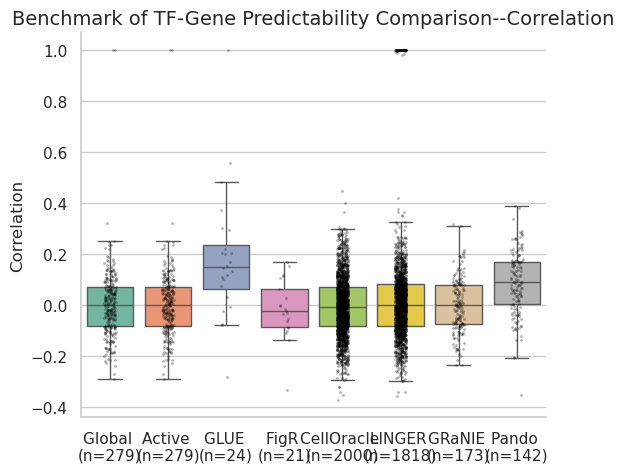

In [15]:
##########################################################################
#
#
##########################################################################

global_result["Method"] = "Global"
active_result["Method"] = "Active"
glue_result["Method"] = "GLUE"
figr_result["Method"] = "FigR"
celloracle_result["Method"] = "CellOracle"
linger_result["Method"] = "LINGER"
granie_result["Method"] = "GRaNIE"
pando_result["Method"] = "Pando"
df_combined = pd.concat([global_result[['Correlation', 'Method']], 
                        active_result[['Correlation', 'Method']],
                        glue_result[['Correlation', 'Method']],
                        figr_result[['Correlation', 'Method']],
                        celloracle_result[['Correlation', 'Method']],
                        linger_result[['Correlation', 'Method']],
                        granie_result[['Correlation', 'Method']],
                        pando_result[['Correlation', 'Method']]])

plt.figure(figsize=(6, 5))

# 定义顺序 (防止自动排序乱掉)
my_order = ['Global', 'Active','GLUE', 'FigR', 'CellOracle', 
            'LINGER', 'GRaNIE', "Pando"]

# 4. 绘制箱形图
# Seaborn 会自动识别 'Method' 列中的组别，并独立计算每个组的箱子
ax = sns.boxplot(data=df_combined, 
                x='Method', 
                y='Correlation', 
                order=my_order, 
                palette="Set2",
                showfliers=False) # 可选：不显示异常值点
sns.stripplot(data=df_combined, x='Method', y='Correlation', 
                order=my_order, color='black', size=2, alpha=0.3, jitter=True, ax=ax)
    
# =================================================
# 关键技巧：修改 X 轴标签，加上 (n=xxx)
# =================================================
# 计算每组的数量
n_A = len(global_result)
n_B = len(active_result)

# 创建新的标签列表
new_labels = [f"Global \n(n={n_A})", f"Active \n(n={n_B})",f"GLUE \n(n={len(glue_result)})",
              f"FigR \n(n={len(figr_result)})", f"CellOracle \n(n={len(celloracle_result)})",
              f"LINGER \n(n={len(linger_result)})", f"GRaNIE \n(n={len(granie_result)})",
              f"Pando \n(n={len(pando_result)})"]

# 应用新标签
ax.set_xticklabels(new_labels)

# 5. 美化
plt.title("Benchmark of TF-Gene Predictability Comparison--Correlation", fontsize=14)
plt.ylabel("Correlation")
plt.xlabel("") # 清空 x 轴标题，因为标签里已经写了

sns.despine() # 去掉边框
plt.savefig(output_path + 'Benchmark of TF-Gene Predictability Comparison--Correlation.png', dpi=1200, bbox_inches='tight')


## Top Correlation

/tmp/ipykernel_7571/1906925413.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df_combined,
/tmp/ipykernel_7571/1906925413.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels)


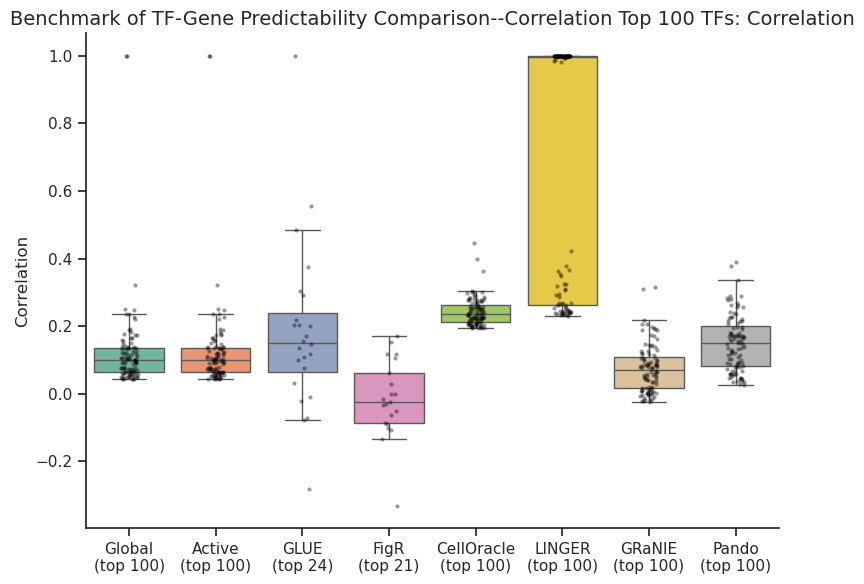

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_top_n_tf_comparison(result_dict, output_path, top_n=50, score_col='Correlation', my_order=None):
    """
    对比不同方法中表现最好的前 N 个 TF
    
    :param result_dict: 字典, key为方法名, value为对应的结果DataFrame
    :param top_n: 取前多少个TF
    :param score_col: 用于排序的列名，通常是 'Correlation' 或 'Precision'
    :param my_order: 指定绘图时的顺序
    """
    processed_list = []
    new_labels = []
    
    # 如果没指定顺序，默认按字典顺序
    if my_order is None:
        my_order = list(result_dict.keys())
        
    for method in my_order:
        if method not in result_dict:
            continue
            
        df = result_dict[method].copy()
        
        # 1. 核心操作：按得分降序排列，取前 N 个
        top_df = df.sort_values(by=score_col, ascending=False).head(top_n)
        top_df["Method"] = method
        processed_list.append(top_df[[score_col, 'Method']])
        
        # 2. 准备新的标签 (n=实际数量)
        actual_n = len(top_df)
        new_labels.append(f"{method}\n(top {actual_n})")
    
    # 合并数据
    df_combined = pd.concat(processed_list)
    
    # 3. 开始绘图
    plt.figure(figsize=(8, 6))
    sns.set_theme(style="ticks")
    
    # 绘制箱线图
    ax = sns.boxplot(data=df_combined, 
                     x='Method', 
                     y=score_col, 
                     order=my_order, 
                     palette="Set2",
                     showfliers=False)
    
    # 叠加散点
    sns.stripplot(data=df_combined, 
                  x='Method', 
                  y=score_col, 
                  order=my_order, 
                  color='black', 
                  size=3, 
                  alpha=0.4, 
                  jitter=True, 
                  ax=ax)
    
    # 4. 美化
    ax.set_xticklabels(new_labels)
    plt.title(f"Benchmark of TF-Gene Predictability Comparison--Correlation Top {top_n} TFs: {score_col}", fontsize=14)
    plt.ylabel(score_col)
    plt.xlabel("")
    
    sns.despine()
    plt.tight_layout()
    plt.savefig(output_path + 'Benchmark of TF-Gene Predictability Comparison--Top 100 TFs Correlation.png',
            dpi=1200, bbox_inches='tight')

# ================= 使用示例 =================

# 1. 将您的结果变量放入字典
all_results = {
    "Global": global_result,
    "Active": active_result,
    "GLUE": glue_result,
    "FigR": figr_result,
    "CellOracle": celloracle_result,
    "LINGER": linger_result,
    "GRaNIE": granie_result,
    "Pando": pando_result
}

# 2. 定义绘图顺序
my_order = ['Global', 'Active', 'GLUE', 'FigR', 'CellOracle', 'LINGER', 'GRaNIE', 'Pando']

# 3. 调用函数，对比前 100 个 TF 的相关性分布
plot_top_n_tf_comparison(all_results, output_path, top_n=100, score_col='Correlation', my_order=my_order)



## Total precision

DyGMAMBA - Precision: 0.1306, Recall: 0.1863, FPR: 0.8014, AUC: 0.1925, F-beta: 0.1389
GLUE - Precision: 0.0000, Recall: 0.0000, FPR: 0.0009, AUC: 0.4995, F-beta: 0.0000
FigR - Precision: 0.1250, Recall: 0.0000, FPR: 0.0008, AUC: 0.4996, F-beta: 0.0002
Pando - Precision: 0.0806, Recall: 0.0002, FPR: 0.0045, AUC: 0.4978, F-beta: 0.0007
CellOracle - Precision: 0.1305, Recall: 0.1864, FPR: 0.8025, AUC: 0.1920, F-beta: 0.1389
LINGER - Precision: 0.1380, Recall: 0.1590, FPR: 0.6108, AUC: 0.2741, F-beta: 0.1417
GRaNIE - Precision: 0.0227, Recall: 0.0000, FPR: 0.0051, AUC: 0.4975, F-beta: 0.0002


/tmp/ipykernel_7571/2680012844.py:140: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Model', y='F-beta', data=result_dataframe.sort_values('F-beta', ascending=False), palette='viridis')


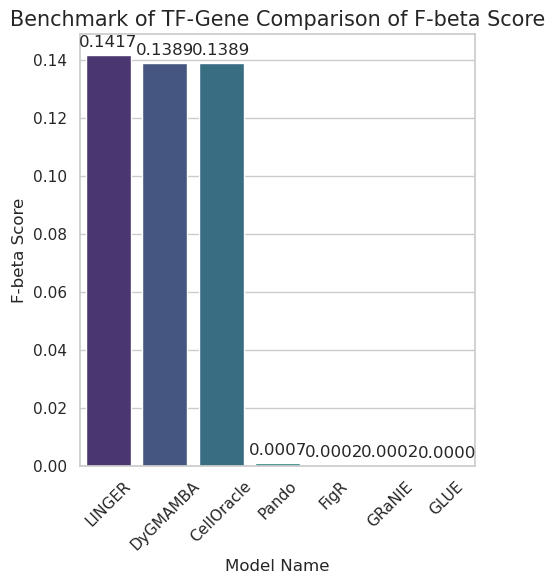

In [17]:
from analysis.assess import glue_read_full_grn
from data_preprocess import adata_to_dataframe


##############################################################################################
# ************************ Benchmark Data **************

cell_type = "GM12878"

data_path = "/home/liyang/BioWuYan/dygmamba_project/data/cell_line/" + cell_type + "/"

benchmark_tf_gene_grn = ad.read_h5ad(data_path + "process/tf_gene_network.h5ad")
    
benchmark_tf_gene_df = adata_to_dataframe(benchmark_tf_gene_grn)

benchmark_tf_gene_df = benchmark_tf_gene_df.rename(columns= {"obs":"TF", "var":"Gene"})

benchmark_tf_gene_threshold = benchmark_tf_gene_df["value"].quantile(0.25)

benchmark_tf_gene_df["label"] = (benchmark_tf_gene_df["value"] > benchmark_tf_gene_threshold).astype(int)

benchmark_tf_gene_df.drop_duplicates(subset=['TF', 'Gene'], inplace=True)
##########################################################################
# dyg TF-Gene predictability

dyg_result_path = data_path + "data_dyg/"
avg_active_tf_gene_df = pd.read_pickle(dyg_result_path + "average_active_tf_gene_grn.pkl")
avg_global_tf_gene_df = pd.read_pickle(dyg_result_path + "average_global_tf_gene_grn.pkl")

dyg_active_tf_gene_grn = avg_active_tf_gene_df[["TF","Gene","avg_total_weight"]].copy()
dyg_active_tf_gene_grn["predict_label"] = (dyg_active_tf_gene_grn["avg_total_weight"]>1).astype(int)
dyg_active_tf_gene_grn.drop_duplicates(subset=['TF', 'Gene'], inplace=True)

##########################################################################
# GLUE TF-Gene predictability
glue_data_path = data_path + "data_glue/"
glue_df = glue_read_full_grn(glue_data_path + 'pruned_grn.csv')
glue_df = glue_df[['TF', 'Target', 'Importance', 'MotifID', 'NES', 'AUC', 'RankAtMax', 'MotifSimilarityQvalue', 'Annotation']]

glue_grn = glue_df[["TF","Target","Importance"]].rename(columns = {"Target":"Gene"})
glue_grn['predict_label'] = (glue_grn["Importance"]>0).astype(int)
glue_grn.drop_duplicates(subset=['TF', 'Gene'], inplace=True)

##########################################################################
# FigR TF-Gene predictability

figr_df = pd.read_csv(data_path + "data_FigR/TF_Gene_Network.csv")
figr_grn = figr_df[["TF","Target_Gene", "Correlation"]].copy()
figr_grn.rename(columns={"Target_Gene": "Gene", "Correlation":"score"}, inplace=True)
figr_grn["score"] = abs(figr_grn["score"])
figr_grn["predict_label"] = (figr_grn["score"]>0).astype(int)
figr_grn.drop_duplicates(subset=['TF', 'Gene'], inplace=True)


##########################################################################
# Celloracle TF-Gene predictability

celloracle_df = pd.read_csv(data_path + "data_celloracle/celloracle_results/grn_df_" + "cluster0" + ".csv")
celloracle_df.rename(columns={"source": "TF", "target": "Gene"}, inplace= True)

celloracle_grn = celloracle_df[["TF", "Gene", "coef_abs"]].copy()
celloracle_grn.rename(columns={"coef_abs": "score"}, inplace=True)
celloracle_grn["predict_label"] = (celloracle_grn["score"]>0).astype(int)
celloracle_grn.drop_duplicates(subset=['TF', 'Gene'], inplace=True)



##########################################################################
# LINGER TF-Gene predictability

linger_df = pd.read_csv(data_path + "data_linger/train/cell_population_trans_regulatory.txt", sep='\t')
linger_df = linger_df.rename(columns={'Unnamed: 0': 'Gene'})
linger_df= linger_df.melt(id_vars=['Gene'], var_name='TF', value_name='regulation')
linger_df.rename(columns={"regulation": "score"}, inplace=True)

linger_grn = linger_df[["TF", "Gene", "score"]].copy()
quantile_value = linger_grn["score"].quantile(0.25)
linger_grn["predict_label"] = (linger_grn["score"] > quantile_value).astype(int)
linger_grn.drop_duplicates(subset=['TF', 'Gene'], inplace=True)

##########################################################################
# GRaNIE TF-Gene predictability

granie_df = pd.read_csv(data_path + "GRaNIE_output/GRaNIE_tf_gene_Links.csv")
granie_df.dropna()
granie_df["score"] = granie_df["TF_peak.r"].abs()* granie_df['peak_gene.r'].abs()

granie_grn = granie_df[["TF.name", "gene.name", "score"]].copy()
granie_grn.rename(columns={"TF.name": "TF", "gene.name": "Gene"}, inplace=True)
granie_grn_quantile = granie_grn["score"].quantile(0.25)
granie_grn["predict_label"] = (granie_grn["score"] > granie_grn_quantile).astype(int)
granie_grn.drop_duplicates(subset=['TF', 'Gene'], inplace=True)


##########################################################################
# Pando TF-Gene predictability

pando_df = pd.read_csv(data_path + "data_pando/tf_gene_network.csv")
pando_df["predict_label"] = (pando_df["padj"]<0.04).astype(int)

pando_grn = pando_df[["TF", "Gene", "predict_label"]].copy()
pando_grn.drop_duplicates(subset=['TF', 'Gene'], inplace=True)


##########################################################################
# result
from analysis.assess import each_confusion_matrix
from analysis.assess import manual_assess

model_dict = {"DyGMAMBA": dyg_active_tf_gene_grn, "GLUE": glue_grn, "FigR": figr_grn,
              "Pando": pando_grn, "CellOracle": celloracle_grn, "LINGER": linger_grn, "GRaNIE": granie_grn}

result_list = []
for model_name, model_df in model_dict.items():
    merged_data = pd.merge(benchmark_tf_gene_df, model_df, on = ["TF", "Gene"], how="outer").fillna(0)
    y_true = merged_data["label"]
    y_pred = merged_data["predict_label"]
    TN, FP, FN, TP = each_confusion_matrix(y_true, y_pred)
    precision, recall, FPR, AUC, f_beta = manual_assess(TN, FP, FN, TP, beta = 0.5 )
    result_list.append({
        "Model": model_name,
        "Precision": precision,
        "Recall": recall,
        "FPR": FPR,
        "AUC": AUC,
        "F-beta": f_beta
    })
    print(f"{model_name} - Precision: {precision:.4f}, Recall: {recall:.4f}, FPR: {FPR:.4f}, AUC: {AUC:.4f}, F-beta: {f_beta:.4f}")

result_dataframe = pd.DataFrame(result_list)

##########################################################################
# figure plot

sns.set_theme(style="whitegrid")
plt.figure(figsize=(5, 6))

# 3. 绘制条形图
# 按照 F-beta 从高到低排序会让图表更有说服力
ax = sns.barplot(x='Model', y='F-beta', data=result_dataframe.sort_values('F-beta', ascending=False), palette='viridis')

# 4. 添加细节
plt.title('Benchmark of TF-Gene Comparison of F-beta Score', fontsize=15)
plt.xlabel('Model Name', fontsize=12)
plt.ylabel('F-beta Score', fontsize=12)
plt.xticks(rotation=45) # 防止模型名称太长重叠

# 在柱状图上方标注具体数值
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.4f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.tight_layout()
plt.savefig(output_path + 'Benchmark of TF-Gene Comparison of F-beta Score.png', dpi=1200, bbox_inches='tight')


/tmp/ipykernel_7571/1970236758.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Model', y='Precision', data=result_dataframe.sort_values('Precision', ascending=False), palette='viridis')


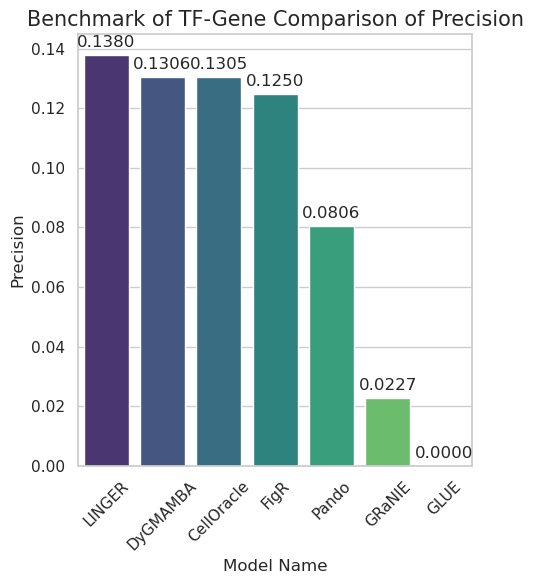

In [18]:
##########################################################################
# figure plot

sns.set_theme(style="whitegrid")
plt.figure(figsize=(5, 6))

# 3. 绘制条形图
# 按照 F-beta 从高到低排序会让图表更有说服力
ax = sns.barplot(x='Model', y='Precision', data=result_dataframe.sort_values('Precision', ascending=False), palette='viridis')

# 4. 添加细节
plt.title('Benchmark of TF-Gene Comparison of Precision', fontsize=15)
plt.xlabel('Model Name', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.xticks(rotation=45) # 防止模型名称太长重叠

# 在柱状图上方标注具体数值
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.4f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.tight_layout()
plt.savefig(output_path + 'Benchmark of TF-Gene Comparison of Precision.png', dpi=1200, bbox_inches='tight')

# Other TF-Region

In [19]:
import sys
import code
import os
import pickle

import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from tqdm import tqdm
import scipy.sparse
from scipy.sparse import csr_matrix
from gtfparse import read_gtf
from collections import defaultdict
from sklearn.metrics import auc, precision_recall_curve, average_precision_score
import dill

import networkx as nx
# 1. 加载 autoreload 扩展
%load_ext autoreload

# 2. 设置模式为 "2" (表示自动重载所有模块)
%autoreload 2


sys.path.append('/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/')

from pdata.data_preprocess import filter_jaspar_tf, adata_to_dataframe
from pdata.data_preprocess import build_tf_peak_network
from analysis.assess_tf_region import calculate_tf_metrics


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Benchmark

In [20]:
cell_type = "GM12878"

f_score = 0.1

data_root = "/home/liyang/BioWuYan/dygmamba_project/data/cell_line/" + cell_type + "/"

data_path = "/home/liyang/BioWuYan/dygmamba_project/data/cell_line/" + cell_type + "/process/"

output_path = "/home/liyang/BioWuYan/dygmamba_project/data/cell_line/" + cell_type + "/benchmark/"

unibind_df_file = "/home/liyang/BioWuYan/dygmamba_project/data/cell_line/" + cell_type + "/benchmark/unibind_df.pkl"

os.makedirs(output_path, exist_ok=True )

adata_atac = ad.read_h5ad(data_path + "atac_processed.h5ad")

##################################################################
# Benchmark TF-Region
# 读取整个文件
tf_chip_seq = pd.read_parquet(data_path + "combined_chip_seq.parquet")
cell_type_chip_seq = tf_chip_seq[["chrom", "start", "end", "tf_name"]].copy()
cell_type_chip_seq.rename(columns={'tf_name':'tf'},inplace = True)
cell_type_chip_seq = cell_type_chip_seq[['tf','chrom','start','end']].copy()

unibind_df = pd.read_pickle(unibind_df_file)
unibind_chip_df = unibind_df[unibind_df['TF'].isin(set(cell_type_chip_seq["tf"]))].copy()

unibind_chip_df = unibind_chip_df[["chrom", "start", "end", "TF"]].copy()
unibind_chip_df.rename(columns={'TF':'tf'},inplace = True)
unibind_chip_df = unibind_chip_df[['tf','chrom','start','end']].copy()

unibind_tf_peak = build_tf_peak_network(adata_atac, unibind_chip_df)
unibind_tf_peak_grn = adata_to_dataframe(unibind_tf_peak)
unibind_tf_peak_grn.rename(columns={'obs':'peak_id', "var":"tf"},inplace = True)
unibind_tf_peak_grn[['chrom', 'start', 'end']] = unibind_tf_peak_grn['peak_id'].str.split('-', expand=True)
unibind_tf_peak_grn['start'] = unibind_tf_peak_grn['start'].astype(int)
unibind_tf_peak_grn['end'] = unibind_tf_peak_grn['end'].astype(int)
unibind_tf_peak_grn.rename(columns={'tf':'TF'},inplace = True)

####################################################################
# dyg TF-Region
jaspar_tf_region_file = data_path + "jaspar_data_processed.h5ad"
jaspar_data = ad.read_h5ad(jaspar_tf_region_file)
adata_region_tf = filter_jaspar_tf(jaspar_data)

coo_matrix = adata_region_tf.X.tocoo()
tf_peak_df = pd.DataFrame({
    'Peak': adata_region_tf.obs_names[coo_matrix.row],
    'TF': adata_region_tf.var_names[coo_matrix.col],
    'value': coo_matrix.data
})
tf_peak_df = tf_peak_df[tf_peak_df["TF"].isin(set(adata_rna.var_names))]
tf_peak_df = tf_peak_df[tf_peak_df["Peak"].isin(set(adata_atac.var_names))]

dyg_results = calculate_tf_metrics(tf_peak_df, unibind_tf_peak_grn, f_beta = f_score)

# dyg_results.to_csv(output_path + "dyg_tf_region_jaspar_unibind_results.csv", index=False)

####################################################################
# GLUE TF-Region

glue_data_path = "/home/liyang/BioWuYan/dygmamba_project/data/cell_line/HepG2/data_glue/"
with open(glue_data_path + "peak2tf.pkl", "rb") as f:
    tf_peak_nx = dill.load(f)
glue_tf_peak_df = nx.to_pandas_edgelist(tf_peak_nx) 
glue_tf_peak_df["value"] = 1
glue_tf_peak_df.rename(columns={'source':'Peak', 'target':'TF'}, inplace=True)

glue_results = calculate_tf_metrics(glue_tf_peak_df, unibind_tf_peak_grn, f_beta = f_score)
print("*"*20 + " GLUE " + "*"*20)
print(glue_results)

##########################################################################
# LINGER TF-Region predictability

linger_grn = pd.read_csv(data_root + "data_linger/train/cell_population_TF_RE_binding.txt", sep='\t')
linger_grn = linger_grn.rename(columns={'Unnamed: 0': 'Peak'})
linger_df= linger_grn.melt(id_vars=['Peak'], var_name='TF', value_name='regulation')
if linger_df['Peak'].str.contains(':').any():
    print("检测到冒号格式，正在统一为连字符格式...")
    # 2. 将冒号替换为连字符
    # 替换前：chr1:100-200 -> 替换后：chr1-100-200
    linger_df['Peak'] = linger_df['Peak'].str.replace(':', '-', regex=False)
    
else:
    print("格式已是连字符（chr1-100-200），无需转换。")
    
linger_results = calculate_tf_metrics(linger_df, unibind_tf_peak_grn, f_beta = f_score)


##########################################################################
# GRaNIE TF-Region predictability

granie_grn = pd.read_csv(data_root + "GRaNIE_output/GRaNIE_tf_region_Links.csv")

granie_df = granie_grn[["TF.name", "peak.ID", "TF_peak.r", "TF_peak.fdr"]].copy()
granie_df.rename(columns={"TF.name": "TF", "peak.ID": "Peak"}, inplace=True)

if granie_df['Peak'].str.contains(':').any():
    print("检测到冒号格式，正在统一为连字符格式...")
    # 2. 将冒号替换为连字符
    # 替换前：chr1:100-200 -> 替换后：chr1-100-200
    granie_df['Peak'] = granie_df['Peak'].str.replace(':', '-', regex=False)
    
else:
    print("格式已是连字符（chr1-100-200），无需转换。")
    
granie_results = calculate_tf_metrics(granie_df, unibind_tf_peak_grn, f_beta = f_score)


##########################################################################
# Pando TF-Region predictability

pando_grn = pd.read_csv(data_root + "data_pando/tf_region_network.csv")

pando_df = pando_grn.copy()
pando_df.rename(columns={"Region": "Peak"}, inplace=True)

if pando_df['Peak'].str.contains(':').any():
    print("检测到冒号格式，正在统一为连字符格式...")
    # 2. 将冒号替换为连字符
    # 替换前：chr1:100-200 -> 替换后：chr1-100-200
    pando_df['Peak'] = pando_df['Peak'].str.replace(':', '-', regex=False)
    
else:
    print("格式已是连字符（chr1-100-200），无需转换。")
    
pando_results = calculate_tf_metrics(pando_df, unibind_tf_peak_grn, f_beta = f_score)

dyg_results['Method'] = 'DYG'
glue_results['Method'] = 'GLUE'
linger_results['Method'] = 'LINGER'
granie_results['Method'] = 'GRaNIE'
pando_results['Method'] = 'Pando'


--- 1. 准备 ATAC Peak 数据 ---
未提供过滤列表，将使用 atac_adata 中所有的 Peaks。
ATAC Peaks 数量: 31278
--- 2. 准备 TF ChIP 数据 ---
TF ChIP Peaks 数量: 1679839
--- 3. 计算重叠 (构建 Network) ---
构建了包含 292643 条边的 TF-Peak 网络。
--- 4. 转换为矩阵 (Matrix Construction) ---
--- 5. 封装为 AnnData ---
✅ 完成！生成的 AnnData 维度: (31278, 47) (Peaks x TFs)

步骤 1: 过滤 Peaks (行)
  > 找到 72283 / 72283 个 peaks 至少有 1 个 TF 结合。

步骤 2: 过滤 TFs (列)
  > 找到 849 / 849 个 TFs 至少结合 1 个 peak。
  > 最终形状: (72283, 849)
正在解析 Consensus Peaks 坐标...
共发现 10 个共有 TF，开始评估...
正在解析 Consensus Peaks 坐标...
共发现 10 个共有 TF，开始评估...
******************** GLUE ********************
      TF  Precision    Recall        F1   TP   FP    FN  GroundTruth_Count  \
0   ATF7   0.474359  0.063032  0.056195   37   41   550                587   
1   TCF3   0.325893  0.187983  0.120408  219  453   946               1165   
2   USF1   0.282927  0.173134  0.108481   58  147   277                335   
3   IRF3   0.045872  0.043103  0.022444   10  208   222                232   
4  NR2F1   0.136029  

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_top_n_comparison(method_dict, output_file, top_n=200, score_col="Precision", palette="Set2"):
    """
    对比多种方法表现最好的前 N 个基因。
    
    参数:
    :param method_dict: 字典，Key 为方法名 (str), Value 为对应的 DataFrame。
    :param top_n: 取前多少个基因进行对比 (int)。
    :param score_col: 用于排序和评价的列名 (str)，如 "Precision", "Spearman_Rho", "F1"。
    :param palette: 绘图配色方案。
    """
    
    combined_list = []
    
    for method_name, df in method_dict.items():
        # 1. 检查列名是否存在
        if score_col not in df.columns:
            print(f"跳过方法 {method_name}: 找不到列 '{score_col}'")
            continue
            
        # 2. 排序并提取前 N 个
        # 深拷贝一份以防修改原始数据，并按降序排序
        temp_df = df.sort_values(by=score_col, ascending=False).head(top_n).copy()
        
        # 3. 添加必要的信息
        temp_df['Method'] = method_name
        temp_df['Rank'] = range(1, len(temp_df) + 1)
        
        combined_list.append(temp_df[['Method', score_col, 'Rank']])
    
    if not combined_list:
        print("错误: 没有有效的数据可以绘制。")
        return None
        
    # 4. 合并所有数据
    df_plot = pd.concat(combined_list)
    
    # ==========================================
    # 5. 开始绘图
    # ==========================================
    sns.set_theme(style="ticks")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # 计算排序逻辑（按中位数从高到低排列箱线图）
    order = df_plot.groupby('Method')[score_col].median().sort_values(ascending=False).index
    
    # --- 图 1: Top N 分布对比 (Boxplot) ---
    sns.boxplot(data=df_plot, x='Method', y=score_col, 
                order=order, palette=palette, width=0.6, ax=ax1)
    sns.stripplot(data=df_plot, x='Method', y=score_col, 
                  order=order, color='black', size=2, alpha=0.3, jitter=True, ax=ax1)
    
    ax1.set_title(f"Top {top_n} Genes: {score_col} Distribution", fontsize=14)
    ax1.set_ylabel(score_col)
    ax1.set_xlabel("")
    ax1.tick_params(axis='x', rotation=45)

    # --- 图 2: 性能衰减曲线 (Line Plot) ---
    sns.lineplot(data=df_plot, x='Rank', y=score_col, 
                 hue='Method', hue_order=order, palette=palette, lw=2.5, ax=ax2)
    
    ax2.set_title(f"Top {top_n} Genes: {score_col} Decay Curve", fontsize=14)
    ax2.set_xlabel("Gene Rank (Sorted by score)")
    ax2.set_ylabel(score_col)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    sns.despine()
    plt.savefig(output_file, dpi=1200, bbox_inches='tight')
    
    return df_plot # 返回处理后的数据，方便后续查阅

/tmp/ipykernel_7571/2112344720.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Method', y=score_col,


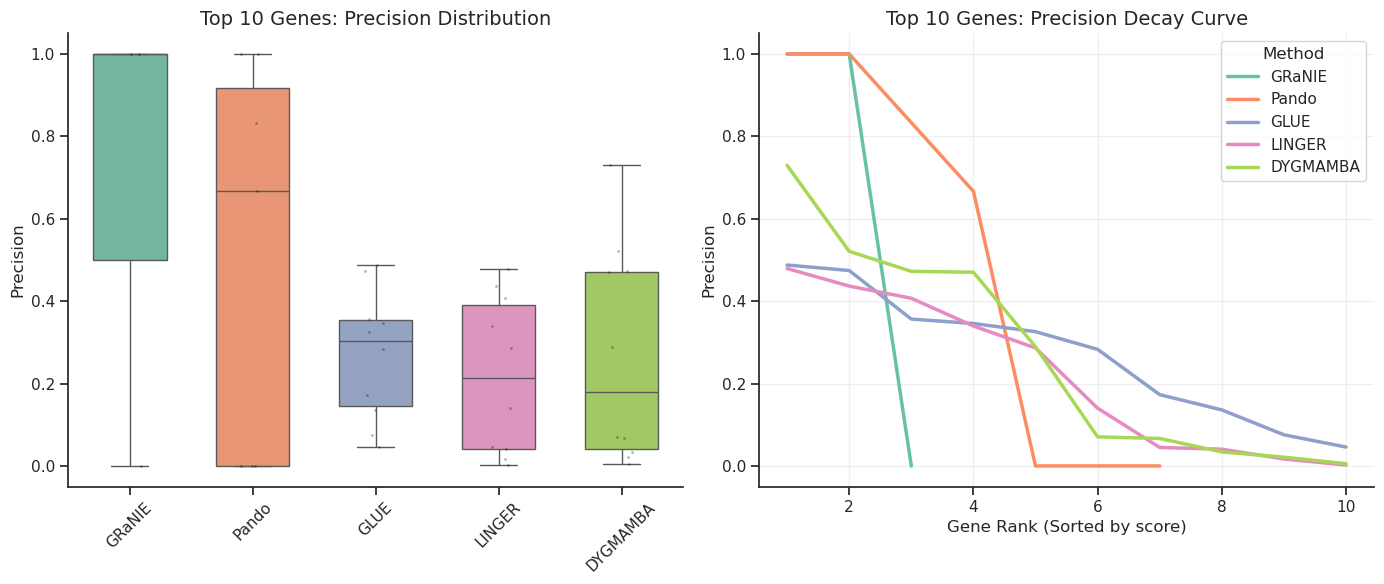

In [22]:
# 1. 准备数据字典
my_methods = {
    "DYGMAMBA": dyg_results,
    "GLUE": glue_results,
    "LINGER": linger_results,
    "GRaNIE": granie_results,
    "Pando": pando_results
}

# 2. 调用函数
# 例如：对比前 200 个基因的 Precision
top_results = plot_top_n_comparison(
    method_dict=my_methods, 
    output_file=output_path + 'Benchmark of TF-Region Comparison of Top 10 Precision.png',
    top_n=10, 
    score_col="Precision"
)


/tmp/ipykernel_7571/2112344720.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Method', y=score_col,


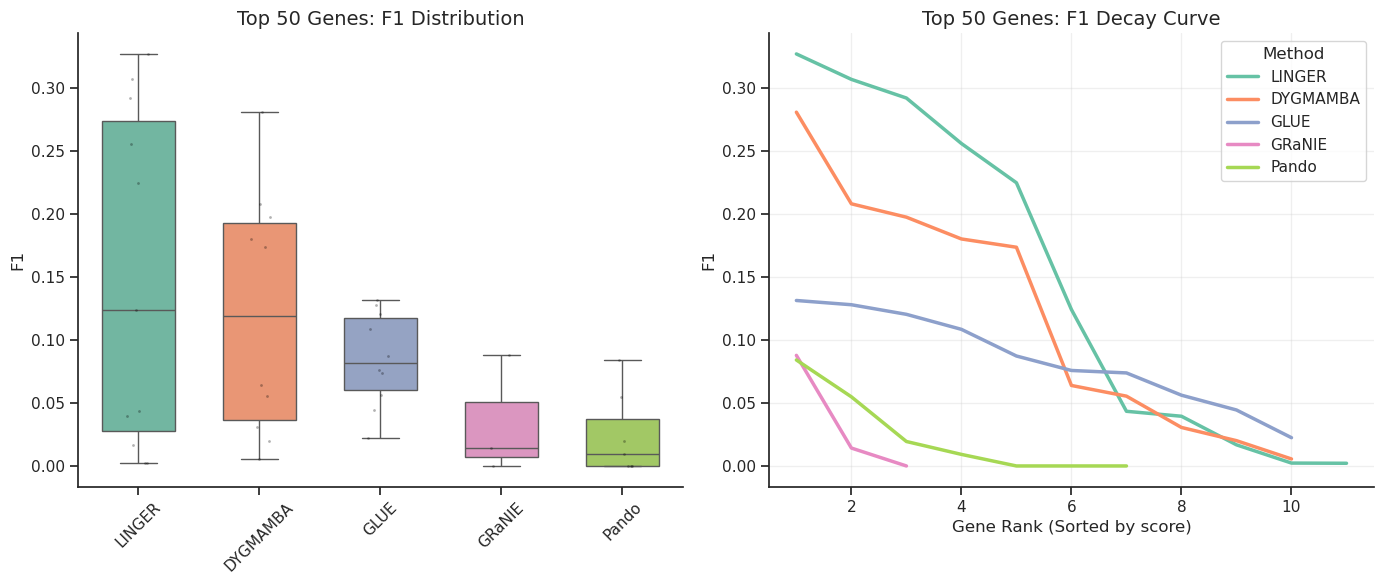

In [23]:
# 2. 调用函数
# 例如：对比前 200 个基因的 Precision
top_results = plot_top_n_comparison(
    method_dict=my_methods, 
    output_file=output_path + 'Benchmark of TF-Region Comparison of Top 50 F1 Score.png',
    top_n=50, 
    score_col="F1"
)


## Precision

/tmp/ipykernel_7571/2435982336.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df_combined,


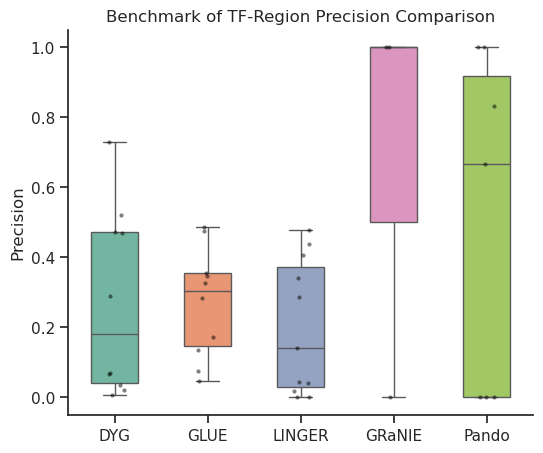

In [24]:
analysis_type = "Precision"

# 拼接在一起 (只取 F1 和 Method 列)
df_combined = pd.concat([dyg_results[[analysis_type, 'Method']], 
                         glue_results[[analysis_type, 'Method']],
                         linger_results[[analysis_type, 'Method']],
                         granie_results[[analysis_type, 'Method']],
                         pando_results[[analysis_type, 'Method']]])

# ==========================================
# 3. 绘制箱形图
# ==========================================
# 设置绘图风格
sns.set_theme(style="ticks")
plt.figure(figsize=(6, 5))

# 画图
ax = sns.boxplot(data=df_combined, 
                 x='Method',    # x轴放分组标签
                 y=analysis_type,        # y轴放数值
                 palette="Set2", # 配色方案
                 width=0.5)     # 箱子宽度

# (可选) 添加抖动散点，展示原始数据点分布
sns.stripplot(data=df_combined, x='Method', y=analysis_type, 
              color='black', size=3, alpha=0.5, jitter=True)

# ==========================================
# 4. 美化与保存
# ==========================================
plt.title("Benchmark of TF-Region Precision Comparison")
plt.ylabel("Precision")
plt.xlabel("") # 去掉 x 轴的 'Method' 字样，因为标签已经很清楚了
sns.despine()  # 去掉上方和右侧的边框，更符合学术规范

# 保存图片
plt.savefig(output_path + 'Benchmark of TF-Region Comparison of Precision.png', dpi=1200, bbox_inches='tight')

## F1 score

/tmp/ipykernel_7571/3514121610.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df_combined,


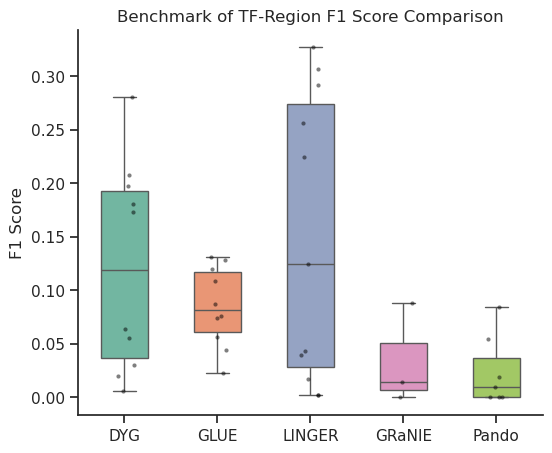

In [25]:

# 拼接在一起 (只取 F1 和 Method 列)
df_combined = pd.concat([dyg_results[['F1', 'Method']], 
                         glue_results[['F1', 'Method']],
                         linger_results[['F1', 'Method']],
                         granie_results[['F1', 'Method']],
                         pando_results[['F1', 'Method']]])

# ==========================================
# 3. 绘制箱形图
# ==========================================
# 设置绘图风格
sns.set_theme(style="ticks")
plt.figure(figsize=(6, 5))

# 画图
ax = sns.boxplot(data=df_combined, 
                 x='Method',    # x轴放分组标签
                 y='F1',        # y轴放数值
                 palette="Set2", # 配色方案
                 width=0.5)     # 箱子宽度

# (可选) 添加抖动散点，展示原始数据点分布
sns.stripplot(data=df_combined, x='Method', y='F1', 
              color='black', size=3, alpha=0.5, jitter=True)

# ==========================================
# 4. 美化与保存
# ==========================================
plt.title("Benchmark of TF-Region F1 Score Comparison")
plt.ylabel("F1 Score")
plt.xlabel("") # 去掉 x 轴的 'Method' 字样，因为标签已经很清楚了
sns.despine()  # 去掉上方和右侧的边框，更符合学术规范

# 保存图片
plt.savefig(output_path + 'Benchmark of TF-Region Comparison of F1 Score.png', dpi=1200, bbox_inches='tight')

# Other Region-Gene

## Benchmark

In [27]:
import sys
import code
import os
import pickle

import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np

from tqdm import tqdm
import scipy.sparse
from scipy.sparse import csr_matrix
from gtfparse import read_gtf
from collections import defaultdict
from sklearn.metrics import auc, precision_recall_curve, average_precision_score
import dill
import networkx as nx
import seaborn as sns

sys.path.append('/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/')


from pdata.data_preprocess import adata_to_dataframe
from benchmark.benchmark_process import Region_Gene_Benchmark

# 1. 加载 autoreload 扩展
%load_ext autoreload

# 2. 设置模式为 "2" (表示自动重载所有模块)
%autoreload 2



from analysis.assess_region_gene import evaluate_per_gene_correlation, evaluate_scenic_plus_correlation, region_gene_evaluate

cell_type ="GM12878"

data_root = "/home/liyang/BioWuYan/dygmamba_project/data/cell_line/"+ cell_type + "/"

data_path = "/home/liyang/BioWuYan/dygmamba_project/data/cell_line/" + cell_type + "/process/"

output_path = "/home/liyang/BioWuYan/dygmamba_project/data/cell_line/" + cell_type + "/benchmark/"

unibind_df_file = "/home/liyang/BioWuYan/dygmamba_project/data/cell_line/" + cell_type + "/benchmark/unibind_df.pkl"

model_result_path = "/home/liyang/BioWuYan/dygmamba_project/data/cell_line/" + cell_type + "/data_dyg/"

os.makedirs(output_path, exist_ok=True )

adata_atac = ad.read_h5ad(data_path + "atac_processed.h5ad")
adata_rna = ad.read_h5ad(data_path + "rna_processed.h5ad")
total_peak = set(adata_atac.var_names)
total_gene = set(adata_rna.var_names)

##################################################################
benchmark_peak_gene_df = pd.read_pickle(data_path + "peak_gene_df.pkl")
benchmark_peak_gene_df = benchmark_peak_gene_df.rename(columns= {"PeakID":"Peak", "gene_name":"Gene","hic_score":"value"})
benchmark_peak_gene_df["label"] = (benchmark_peak_gene_df["value"]>0).astype(int)
benchmark_peak_gene_df = benchmark_peak_gene_df[benchmark_peak_gene_df["Peak"].isin(total_peak)].copy()
benchmark_peak_gene_df = benchmark_peak_gene_df[benchmark_peak_gene_df["Gene"].isin(total_gene)].copy()

df_hic = benchmark_peak_gene_df.copy()
df_hic = df_hic.rename(columns={"Peak":"region", "Gene":"gene"})

############################################################################################

Markrer_Genes = adata_rna.var["highly_variable_rank"].copy()
Markrer_Genes = Markrer_Genes.sort_values()
top_marker_genes = list(Markrer_Genes.index[:100])

############################################################################################
# DYGMAMBA peak-gene grn
    
Node_id = pd.read_pickle(model_result_path + "node_id.pkl")
graph_df = pd.read_pickle(model_result_path + "Graph_df.pkl")
graph_df["Unnamed"] = graph_df.index
name_list = ["Unnamed", "source_node", "target_node", "time", "label", "edge_idx"]
New_Graph = graph_df[name_list].copy()
New_Graph.columns = ['Unnamed: 0', 'u', 'i', 'ts', 'label', 'idx']

result_path = model_result_path + 'my_result_run0.npy'
predict_edge_label = np.load(result_path)

# binary_output = (predict_edge_label > 0.5).astype(int)
New_Graph["predict"] = predict_edge_label
dyg_predict_grn = New_Graph.copy()

mapping_series = Node_id["name"]
dyg_predict_grn['source'] = (dyg_predict_grn['u'] - 1).map(mapping_series)
dyg_predict_grn['target'] = (dyg_predict_grn['i'] - 1).map(mapping_series)

dyg_peak_gene_df = dyg_predict_grn[['source', 'target', 'ts','predict']].rename(
    columns={'source': 'Peak', 'target': 'Gene'}
)
dyg_peak_gene_df = dyg_peak_gene_df[~dyg_peak_gene_df["Gene"].str.startswith('chr')].copy()
    
####################################################################################

avg_active_peak_gene_grn = dyg_peak_gene_df.groupby(['Peak', 'Gene']).agg(
    avg_ts_weight=('predict', 'mean'),  # 对 weight 列做均值，新列名叫 avg_weight
    avg_total_weight=('predict', 'sum')  # (可选) 建议顺便算个总权重
).reset_index()
avg_active_peak_gene_grn = avg_active_peak_gene_grn[avg_active_peak_gene_grn["Peak"].isin(total_peak)].copy()

avg_active_peak_gene_grn["predict"] = (avg_active_peak_gene_grn["avg_ts_weight"]> 0.9).astype(int)

avg_active_peak_gene_grn.drop_duplicates(subset=["Peak", "Gene"], inplace=True)
avg_active_peak_gene_grn.dropna()

df_pred = avg_active_peak_gene_grn.copy()
df_pred = df_pred.rename(columns={"Peak":"region", "Gene":"gene", "avg_ts_weight":"value"})
avg_active_peak_gene_grn["value"] = avg_active_peak_gene_grn["avg_ts_weight"]

dyg_peak_gene_result = region_gene_evaluate(benchmark_peak_gene_df, avg_active_peak_gene_grn, 
                                            model_name="DYGMAMBA", output_path=output_path)

dyg_corr_score, dyg_plot_data = evaluate_scenic_plus_correlation(df_pred, df_hic, 
                                                            marker_genes=top_marker_genes)
print("*"*50)
print("*"*20 + " DYGMAMBA " + "*"*20)
print(dyg_corr_score)
print("*"*50)
print(dyg_results)
print("*"*50)
print(dyg_peak_gene_result)
#######################################################################################
#
#
#######################################################################################
# GLUE peak-gene grn

glue_data_path = "/home/liyang/BioWuYan/dygmamba_project/data/cell_line/HepG2/data_glue/"

with open(glue_data_path + "gene2peak.pkl", "rb") as f:
    gene_peak_nx = dill.load(f)
glue_gene_peak_df = nx.to_pandas_edgelist(gene_peak_nx)

glue_gene_peak_df.drop_duplicates(subset=["source", "target"], inplace=True)
glue_gene_peak_df.rename(columns={'source':'Gene', 'target':'Peak', 'weight':'predict'}, inplace=True)
glue_gene_peak_df["predict"] = (glue_gene_peak_df["predict"]>0.9).astype(int)
glue_gene_peak_df["value"] = glue_gene_peak_df["score"]
glue_pred = glue_gene_peak_df[["Peak", "Gene", "value"]].copy()
glue_pred = glue_pred.rename(columns={"Peak":"region", "Gene":"gene"})

glue_peak_gene_result = region_gene_evaluate(benchmark_peak_gene_df, glue_gene_peak_df, 
                                            model_name="GLUE", output_path=output_path)  

glue_corr_score, glue_plot_data = evaluate_scenic_plus_correlation(glue_pred, df_hic, 
                                                                    marker_genes=top_marker_genes)

#######################################################################################
# Pando peak-gene grn

pando_grn = pd.read_csv(data_root + "data_pando/region_gene_network.csv")
pando_grn.drop_duplicates(subset=["Region", "Gene"], inplace=True)
pando_grn.dropna()
pando_gene_peak_df = pando_grn.copy()
pando_gene_peak_df.rename(columns={"Region": "Peak"}, inplace=True)
pando_gene_peak_df["predict"] = (pando_gene_peak_df["padj"]<0.05).astype(int)
pando_gene_peak_df["value"] = -np.log10(pando_gene_peak_df["padj"])
pando_pred = pando_gene_peak_df[["Peak", "Gene", "value"]].copy()
pando_pred = pando_pred.rename(columns={"Peak":"region", "Gene":"gene"})

pando_peak_gene_result = region_gene_evaluate(benchmark_peak_gene_df, pando_gene_peak_df, 
                                            model_name="Pando", output_path=output_path)  

pando_corr_score, pando_plot_data = evaluate_scenic_plus_correlation(pando_pred, df_hic, 
                                                                    marker_genes=top_marker_genes)



#######################################################################################
# FigR peak-gene grn
figr_grn = pd.read_csv(data_root + "data_FigR/Region_Gene_Network.csv")
if figr_grn['Region'].str.contains(':').any():
    print("检测到冒号格式，正在统一为连字符格式...")
    # 2. 将冒号替换为连字符
    # 替换前：chr1:100-200 -> 替换后：chr1-100-200
    figr_grn['Region'] = figr_grn['Region'].str.replace(':', '-', regex=False)
    
else:
    print("格式已是连字符（chr1-100-200），无需转换。")

figr_grn.drop_duplicates(subset=["Region", "Target_Gene"], inplace=True)

figr_gene_peak_df = figr_grn.copy()
figr_gene_peak_df.rename(columns={"Region": "Peak", "Target_Gene":"Gene"}, inplace=True)
figr_gene_peak_df["predict"] = (figr_gene_peak_df["P_Value"]<0.05).astype(int)
figr_gene_peak_df["value"] = figr_gene_peak_df["Correlation"]

figr_pred = figr_gene_peak_df[["Peak", "Gene", "value"]].copy()
figr_pred = figr_pred.rename(columns={"Peak":"region", "Gene":"gene"})

figr_peak_gene_result = region_gene_evaluate(benchmark_peak_gene_df, figr_gene_peak_df, 
                                            model_name="FigR", output_path=output_path)  

figr_corr_score, figr_plot_data = evaluate_scenic_plus_correlation(figr_pred, df_hic, 
                                                                    marker_genes=top_marker_genes)

#######################################################################################
# LINGER peak-gene grn

linger_grn = pd.read_csv(data_root + "data_linger/train/cell_population_cis_regulatory.txt", 
                         sep='\t', header=None, names=["Peak", "Gene", "reg"])

if linger_grn['Peak'].str.contains(':').any():
    print("检测到冒号格式，正在统一为连字符格式...")
    # 2. 将冒号替换为连字符
    # 替换前：chr1:100-200 -> 替换后：chr1-100-200
    linger_grn['Peak'] = linger_grn['Peak'].str.replace(':', '-', regex=False)
    
else:
    print("格式已是连字符（chr1-100-200），无需转换。")

linger_grn.drop_duplicates(subset=["Peak", "Gene"], inplace=True)

linger_gene_peak_df = linger_grn.copy()
linger_gene_peak_df["predict"] = (linger_gene_peak_df["reg"]<0.05).astype(int)
linger_gene_peak_df["value"] = -np.log10(linger_gene_peak_df["reg"])

linger_pred = linger_gene_peak_df[["Peak", "Gene", "value"]].copy()
linger_pred = linger_pred.rename(columns={"Peak":"region", "Gene":"gene"})

linger_peak_gene_result = region_gene_evaluate(benchmark_peak_gene_df, linger_gene_peak_df, 
                                            model_name="LINGER", output_path=output_path)

linger_corr_score, linger_plot_data = evaluate_scenic_plus_correlation(linger_pred, df_hic, 
                                                                    marker_genes=top_marker_genes)

#######################################################################################
# GRaNIE peak-gene grn

granie_grn = pd.read_csv(data_root + "GRaNIE_output/GRaNIE_region_gene_Links.csv")

if granie_grn['peak.ID'].str.contains(':').any():
    print("检测到冒号格式，正在统一为连字符格式...")
    # 2. 将冒号替换为连字符
    # 替换前：chr1:100-200 -> 替换后：chr1-100-200
    granie_grn['peak.ID'] = granie_grn['peak.ID'].str.replace(':', '-', regex=False)
    
else:
    print("格式已是连字符（chr1-100-200），无需转换。")
granie_grn.dropna()

granie_grn = granie_grn.rename(columns={"peak.ID":"Peak", "gene.name":"Gene"})
granie_grn.dropna()
granie_grn.drop_duplicates(subset=["Peak", "Gene"], inplace=True)

granie_gene_peak_df = granie_grn.copy()

granie_gene_peak_df["predict"] = 1
granie_gene_peak_df["value"] = -np.log10(granie_gene_peak_df["peak_gene.p_adj"])

granie_pred = granie_gene_peak_df[["Peak", "Gene", "value"]].copy()
granie_pred = granie_pred.rename(columns={"Peak":"region", "Gene":"gene"})

granie_peak_gene_result = region_gene_evaluate(benchmark_peak_gene_df, granie_gene_peak_df, 
                                            model_name="GRaNIE", output_path=output_path)

granie_corr_score, granie_plot_data = evaluate_scenic_plus_correlation(granie_pred, df_hic,
                                                                    marker_genes=top_marker_genes)

#######################################################################################
# results analysis

results = pd.DataFrame({"GRaNIE":abs(granie_corr_score), "FigR":abs(figr_corr_score), 
                        "LINGER":abs(linger_corr_score), "Pando":abs(pando_corr_score), 
                        "GLUE":abs(glue_corr_score), "DYGMAMBA":abs(dyg_corr_score)}, index=[0])



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/analysis/assess_region_gene.py:54: RuntimeWarning: invalid value encountered in scalar divide
  model_FPR = float(model_FP/(model_FP+model_TN))
/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/analysis/assess_region_gene.py:52: RuntimeWarning: invalid value encountered in scalar divide
  model_precision = float(model_TP/(model_TP+model_FP))
/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/analysis/assess_region_gene.py:53: RuntimeWarning: invalid value encountered in scalar divide
  model_recall = float(model_TP/(model_TP+model_FN))
/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/analysis/assess_region_gene.py:54: RuntimeWarning: invalid value encountered in scalar divide
  model_FPR = float(model_FP/(model_FP+model_TN))


**************************************************
merged: 79006, benchmark peak gene: 112325,        dyg peak gene 50089
Peak-Gene: 30331,         1999, edge:79006
Merged Peak-Gene: 30331, 1999,         79006
DYGMAMBA Peak-Gene: 31194, 2000,         edge: 50089
Benchmark Peak-Gene: 30571,         1999, edge: 112325
**************************************************
正在筛选 100 个 Marker Genes...
正在合并预测数据与 Hi-C 数据...
共找到 4157 个重叠的 Region-Gene 连接用于评估。
评估结果 (spearman): Correlation = -0.0973 (P-value = 3.26e-10)
**************************************************
******************** DYGMAMBA ********************
-0.0972896421007376
**************************************************
      TF  Precision    Recall        F1    TP    FP    FN  GroundTruth_Count  \
0   MAFK   0.005529  0.854839  0.005549    53  9532     9                 62   
1   IRF4   0.470146  0.287688  0.180261  2874  3239  7116               9990   
2   JUND   0.289333  0.603896  0.197569  2604  6396  1708               4312

/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/analysis/assess_region_gene.py:54: RuntimeWarning: invalid value encountered in scalar divide
  model_FPR = float(model_FP/(model_FP+model_TN))
/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/analysis/assess_region_gene.py:54: RuntimeWarning: invalid value encountered in scalar divide
  model_FPR = float(model_FP/(model_FP+model_TN))
/home/liyang/BioWuYan/conda_env/dygmamba39/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


**************************************************
merged: 88196, benchmark peak gene: 112325,        dyg peak gene 90385
Peak-Gene: 25664,         1816, edge:88196
Merged Peak-Gene: 25664, 1816,         88196
LINGER Peak-Gene: 26453, 1816,         edge: 90385
Benchmark Peak-Gene: 30571,         1999, edge: 112325
**************************************************
正在筛选 100 个 Marker Genes...
正在合并预测数据与 Hi-C 数据...
共找到 4740 个重叠的 Region-Gene 连接用于评估。
评估结果 (spearman): Correlation = -0.0181 (P-value = 2.12e-01)
检测到冒号格式，正在统一为连字符格式...
**************************************************
merged: 316, benchmark peak gene: 112325,        dyg peak gene 176
Peak-Gene: 111,         167, edge:316
Merged Peak-Gene: 111, 167,         316
GRaNIE Peak-Gene: 114, 173,         edge: 176
Benchmark Peak-Gene: 30571,         1999, edge: 112325
**************************************************
正在筛选 100 个 Marker Genes...
正在合并预测数据与 Hi-C 数据...
共找到 8 个重叠的 Region-Gene 连接用于评估。
警告：重叠连接数过少，相关性计算可能不可靠。
评估结果 (spearman): Co

/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/analysis/assess_region_gene.py:54: RuntimeWarning: invalid value encountered in scalar divide
  model_FPR = float(model_FP/(model_FP+model_TN))
/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/analysis/assess_region_gene.py:54: RuntimeWarning: invalid value encountered in scalar divide
  model_FPR = float(model_FP/(model_FP+model_TN))


## Average score

/tmp/ipykernel_7571/2836409193.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Method', y='Correlation', data=plot_data, palette='coolwarm')


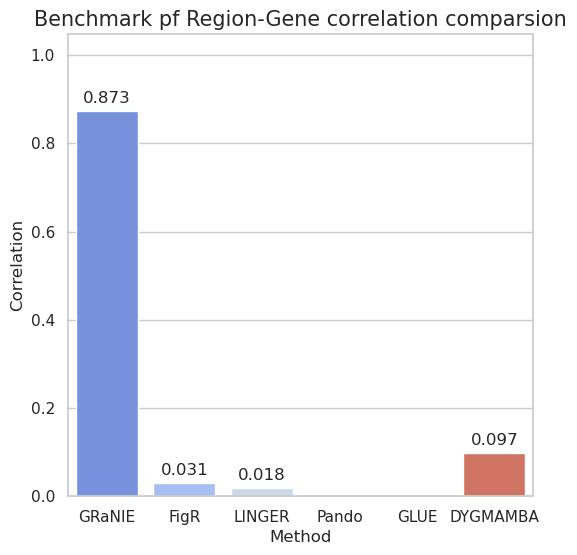

In [28]:
plot_data = results.T.reset_index()
plot_data.columns = ['Method', 'Correlation']

# 2. 绘图
plt.figure(figsize=(6, 6))
sns.set_style("whitegrid") # 设置清爽的白色网格背景

# 使用你喜欢的配色，比如 'viridis' 或 'magma'
ax = sns.barplot(x='Method', y='Correlation', data=plot_data, palette='coolwarm')

# 在柱子上方自动添加数值标签
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.3f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.title("Benchmark pf Region-Gene correlation comparsion", fontsize=15)
plt.ylim(0, max(plot_data['Correlation']) * 1.2) # 给上方数值留点空间
plt.savefig(output_path + 'Benchmark of Region-Gene Correlation Comparison.png', dpi=1200, bbox_inches='tight')

## Top score

/tmp/ipykernel_7571/570190315.py:121: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(group['value_bench'], group['value_method'])
/tmp/ipykernel_7571/570190315.py:124: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gene_rhos = merged.groupby('Gene').apply(get_gene_cor).dropna()
/tmp/ipykernel_7571/570190315.py:121: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(group['value_bench'], group['value_method'])
/tmp/ipykernel_7571/570190315.py:124: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future v

                 Peak    Gene  value_bench  label  value_method
0  chr1-778414-779184    AGRN    22.184526      1           0.0
1  chr1-778414-779184    AGRN    14.272410      1           0.0
2  chr1-778414-779184    CPTP    17.408941      1           0.0
3  chr1-778414-779184  CDK11B    19.130083      1           0.0
4  chr1-804419-805575    AGRN    20.916346      1           0.0
                 Peak    Gene  value_bench  label  value_method
0  chr1-778414-779184    AGRN    22.184526      1           0.0
1  chr1-778414-779184    AGRN    14.272410      1           0.0
2  chr1-778414-779184    CPTP    17.408941      1           0.0
3  chr1-778414-779184  CDK11B    19.130083      1           0.0
4  chr1-804419-805575    AGRN    20.916346      1           0.0


/tmp/ipykernel_7571/570190315.py:124: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gene_rhos = merged.groupby('Gene').apply(get_gene_cor).dropna()
/tmp/ipykernel_7571/570190315.py:121: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(group['value_bench'], group['value_method'])


                 Peak    Gene  value_bench  label  value_method
0  chr1-778414-779184    AGRN    22.184526      1      0.990997
1  chr1-778414-779184    AGRN    14.272410      1      0.990997
2  chr1-778414-779184    CPTP    17.408941      1      0.000000
3  chr1-778414-779184  CDK11B    19.130083      1      0.000000
4  chr1-804419-805575    AGRN    20.916346      1      0.976367


/tmp/ipykernel_7571/570190315.py:124: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gene_rhos = merged.groupby('Gene').apply(get_gene_cor).dropna()
/tmp/ipykernel_7571/570190315.py:121: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(group['value_bench'], group['value_method'])


...

/tmp/ipykernel_7571/570190315.py:124: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gene_rhos = merged.groupby('Gene').apply(get_gene_cor).dropna()
/tmp/ipykernel_7571/570190315.py:121: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(group['value_bench'], group['value_method'])


                 Peak    Gene  value_bench  label  value_method
0  chr1-778414-779184    AGRN    22.184526      1           0.0
1  chr1-778414-779184    AGRN    14.272410      1           0.0
2  chr1-778414-779184    CPTP    17.408941      1           0.0
3  chr1-778414-779184  CDK11B    19.130083      1           0.0
4  chr1-804419-805575    AGRN    20.916346      1           0.0


/tmp/ipykernel_7571/570190315.py:124: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gene_rhos = merged.groupby('Gene').apply(get_gene_cor).dropna()


                 Peak    Gene  value_bench  label  value_method
0  chr1-778414-779184    AGRN    22.184526      1      2.098749
1  chr1-778414-779184    AGRN    14.272410      1      2.098749
2  chr1-778414-779184    CPTP    17.408941      1      0.000000
3  chr1-778414-779184  CDK11B    19.130083      1      2.156112
4  chr1-804419-805575    AGRN    20.916346      1      0.000000
计算 LINGER 的 AUPRC 时出错: Input contains infinity or a value too large for dtype('float64').


/tmp/ipykernel_7571/570190315.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_n_df = corr_df.groupby('Method').apply(
/tmp/ipykernel_7571/570190315.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


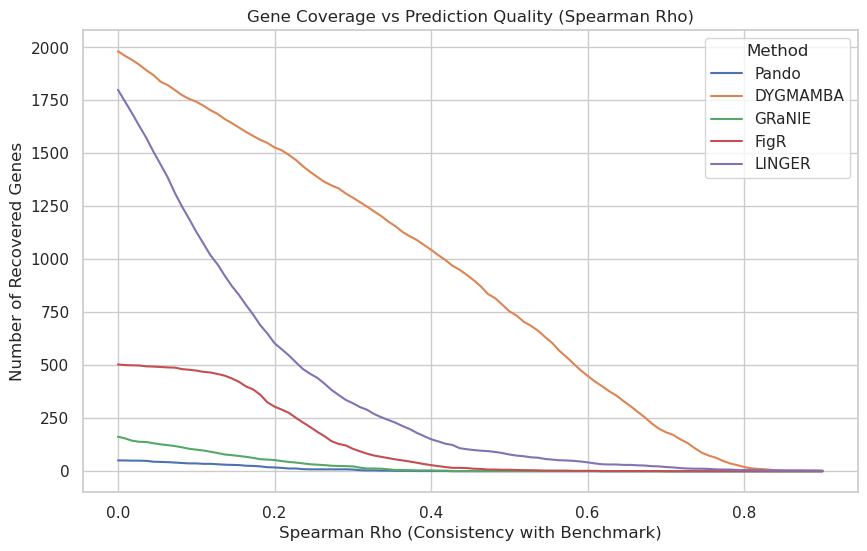

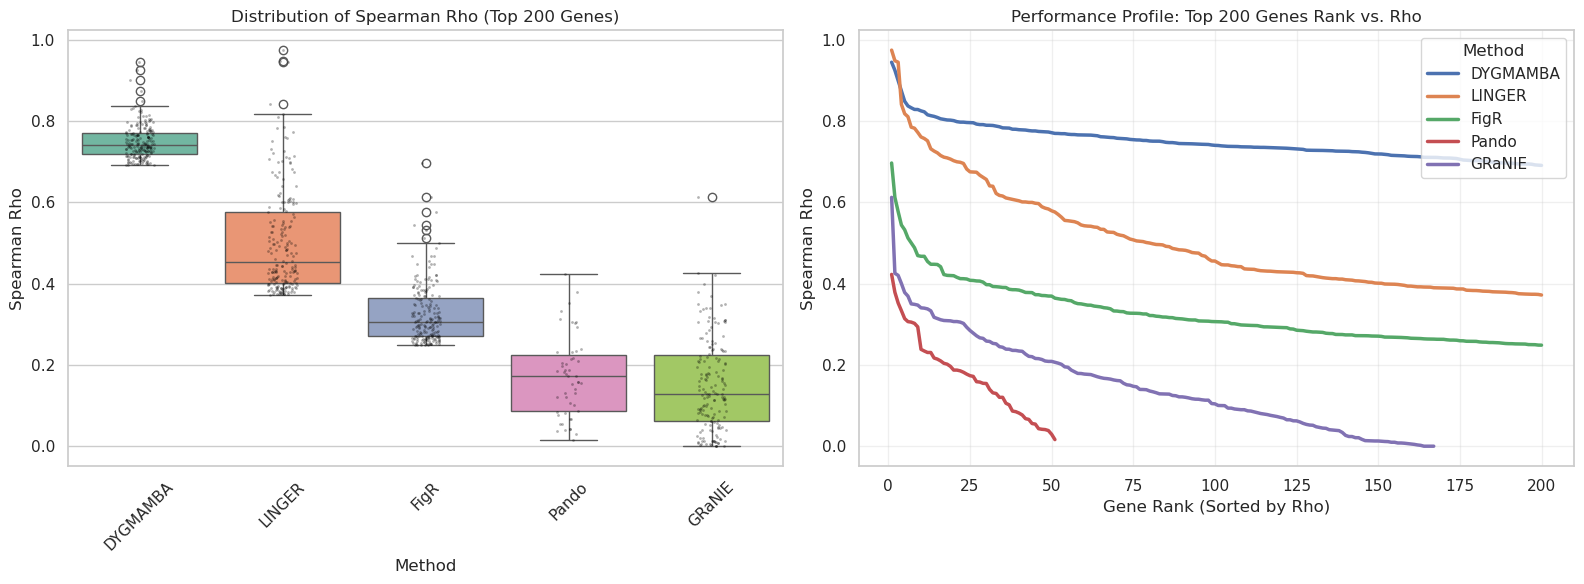

In [29]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.metrics import average_precision_score


def plot_top_n_methods_comparison(corr_df, output_file, top_n=100, compare_method = 'Spearman_Rho'):
    """
    提取每种方法相关性最好的前 N 个基因并进行比较
    :param corr_df: 包含 [Method, Gene, Spearman_Rho] 的 DataFrame
    :param top_n: 每种方法选取的基因数量
    """
    # 1. 提取每种方法的前 N 个基因
    top_n_df = corr_df.groupby('Method').apply(
        lambda x: x.sort_values(compare_method, ascending=False).head(top_n)
    ).reset_index(drop=True)

    # 2. 为绘图计算排名（Rank 1 到 N）
    top_n_df['Rank'] = top_n_df.groupby('Method')[compare_method].rank(
        ascending=False, method='first'
    ).astype(int)

    # 创建画布
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # --- 图 1: Top N 基因的相关性分布 (Boxplot) ---
    # 这展示了各方法“天花板”的平均水平
    method_order = top_n_df.groupby('Method')[compare_method].median().sort_values(ascending=False).index
    
    sns.boxplot(
        data=top_n_df, x='Method', y=compare_method, 
        order=method_order, palette='Set2', ax=ax1
    )
    sns.stripplot(
        data=top_n_df, 
        x='Method', 
        y=compare_method, 
        order=method_order, 
        color='black', 
        alpha=0.3, 
        size=2, 
        jitter=True,
        ax=ax1
        )
    ax1.set_title(f'Distribution of Spearman Rho (Top {top_n} Genes)')
    ax1.set_ylabel('Spearman Rho')
    ax1.tick_params(axis='x', rotation=45)

    # --- 图 2: Top N 基因的相关性衰减曲线 (Line Plot) ---
    # 这展示了随着排名增加，高质量预测消失的速度
    sns.lineplot(
        data=top_n_df, x='Rank', y=compare_method, 
        hue='Method', hue_order=method_order, lw=2.5, ax=ax2
    )

    ax2.set_title(f'Performance Profile: Top {top_n} Genes Rank vs. Rho')
    ax2.set_xlabel('Gene Rank (Sorted by Rho)')
    ax2.set_ylabel('Spearman Rho')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(output_file, dpi=1200, bbox_inches='tight')


def plot_recovery_curves(corr_df, output_file, compared_method='Spearman_Rho'):
    """
    恢复曲线：X轴是相关性阈值，Y轴是该方法在该质量下能覆盖的基因总数
    """
    thresholds = np.linspace(0, 0.9, 100) # 覆盖从低到高的相关性区间
    plot_list = []
    
    for method in corr_df['Method'].unique():
        m_vals = corr_df[corr_df['Method'] == method][compared_method].values
        for thr in thresholds:
            count = np.sum(m_vals > thr)
            plot_list.append({'Method': method, 'Threshold': thr, 'Gene_Count': count})
            
    pdf = pd.DataFrame(plot_list)
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=pdf, x='Threshold', y='Gene_Count', hue='Method')
    plt.title('Gene Coverage vs Prediction Quality (Spearman Rho)')
    plt.ylabel('Number of Recovered Genes')
    plt.xlabel('Spearman Rho (Consistency with Benchmark)')
    plt.savefig(output_file, dpi=1200, bbox_inches='tight')





def evaluate_r2g_benchmark(benchmark_df, method_dict, min_links=5):
    """
    评估 R2G 预测性能
    :param benchmark_df: 金标准 [Peak, Gene, value, label]
    :param method_dict: 方法字典，如 {'GRaNIE': df1, 'GLUE': df2}
    :param min_links: 每个基因计算相关性所需的最少边数
    """
    correlation_results = []
    global_metrics = []
    
    # 1. 计算每个基因的相关性（关注质量）
    for method_name, pred_df in method_dict.items():
        # 合并预测与金标准
        merged = pd.merge(
            benchmark_df[['Peak', 'Gene', 'value', 'label']], 
            pred_df[['Peak', 'Gene', 'value']], 
            on=['Peak', 'Gene'],
            how='left',
            suffixes=('_bench', '_method')
        )
        merged['value_method'] = merged['value_method'].fillna(0)
        if merged.empty:
            print(f"警告: 方法 {method_name} 与金标准无共有 Peak-Gene 对，跳过。")
            continue
        # 按基因分组计算 Spearman Rho
        def get_gene_cor(group):
            if len(group) < min_links:
                return np.nan
            # 使用预测分值与金标准连续值（如 Hi-C score）计算相关性
            rho, _ = spearmanr(group['value_bench'], group['value_method'])
            return rho

        gene_rhos = merged.groupby('Gene').apply(get_gene_cor).dropna()
        
        for gene, rho in gene_rhos.items():
            correlation_results.append({
                'Method': method_name,
                'Gene': gene,
                'Spearman_Rho': rho
            })
        print(merged.head())
        try:
            auprc = average_precision_score(merged['label'], merged['value_method'])
            global_metrics.append({
                'Method': method_name, 
                'AUPRC': auprc, 
                'Total_Links': len(pred_df),
                'Common_Links': len(merged)
            })
        except Exception as e:
            print(f"计算 {method_name} 的 AUPRC 时出错: {e}")
            

    corr_df = pd.DataFrame(correlation_results)
    metrics_df = pd.DataFrame(global_metrics)
    
    return corr_df, metrics_df



###########################################
# 
method_data = {"Pando":pando_gene_peak_df, "GLUE":glue_gene_peak_df, "DYGMAMBA":avg_active_peak_gene_grn,
               "GRaNIE":granie_gene_peak_df, "FigR":figr_gene_peak_df, "LINGER":linger_gene_peak_df}

corr_df, metrics_df = evaluate_r2g_benchmark(benchmark_peak_gene_df, method_data)


# 使用示例：
# 假设 top_n=200，比较各方法最准的 200 个基因
corr_df['Abs_Spearman_Rho'] = corr_df['Spearman_Rho'].abs()

# 调用
plot_recovery_curves(corr_df, 
                     output_file=output_path + 'Benchmark of Recovery Curve of Region-Gene Prediction.png',
                     compared_method='Abs_Spearman_Rho')

plot_top_n_methods_comparison(corr_df, 
                              output_file=output_path + 'Benchmark of Region-Gene Comparison of Top 200 Spearman Rho.png',
                              top_n=200, compare_method='Abs_Spearman_Rho')


# TEST